# Summative Lab: DataVine Analytics – Customer Insights & Machine Learning

This starter notebook uses two prepared retail datasets derived from the Online Retail II transactional data:

- `customer_level_online_retail.csv`
- `product_level_online_retail.csv`

You will:
1. Load and inspect both datasets
2. Join them into one analytical dataset
3. Build a **k-NN classification** model to predict customer value segment
4. Build a **product recommendation system**
5. Perform **customer clustering** with K-Means and GMM

**Important:** Keep your code concise, but explain your thinking in comments and markdown.

## Step 0: Import libraries

Add any additional imports you need, but try to keep your notebook focused and readable.

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

## Step 1: Load, explore, and prepare the data

Load the two CSV files and inspect their structure.

In [5]:
# Load the customer-level and product-level datasets.
# Hint: Use pd.read_csv() with the two CSV file names provided for the lab.

customer_df = pd.read_csv("customer_level_online_retail.csv")
product_df = pd.read_csv("product_level_online_retail.csv")

# Display the first few rows of each dataset so you can see what fields are available.
display(customer_df.head())
display(product_df.head())

,CustomerID,Country,FirstPurchaseDate,LastPurchaseDate,NumInvoices,TotalUnits,TotalSpend,UniqueProducts,FavoriteStockCode,FavoriteProductDescription,...,DiversityRatio,TopCategoryShare,CategoryDiversity,Share_StorageBags,Share_GeneralGifts,Share_HomeDecor,Share_KitchenDining,Share_StationeryCrafts,CountryGroup,ValueSegment
0,12346,United Kingdom,2009-12-14 08:34:00,2011-01-18 10:01:00,12,74285,77556.46,27,TEST001,This is a test product.,...,0.000363,0.999058,4,0.000000,0.000902,0.000000,0.999058,0.000000,UK,High
1,12347,Iceland,2010-10-31 14:20:00,2011-12-07 15:52:00,8,3286,5633.32,126,84558A,3D DOG PICTURE PLAYING CARDS,...,0.038344,0.351187,9,0.256239,0.351187,0.111990,0.093731,0.055386,Europe,High
2,12348,Finland,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,25,POST,POSTAGE,...,0.009211,0.447310,5,0.282977,0.447310,0.137067,0.000000,0.128224,Europe,High
3,12349,Italy,2010-04-29 13:20:00,2011-11-21 09:51:00,4,1624,4428.69,138,22555,PLASTERS IN TIN STRONGMAN,...,0.084975,0.250000,8,0.179187,0.250000,0.152094,0.190271,0.160714,Europe,High
4,12350,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,17,21908,CHOCOLATE THIS WAY METAL SIGN,...,0.086294,0.583756,3,0.182741,0.583756,0.000000,0.233503,0.000000,Europe,Low


,StockCode,Description,Category,AvgUnitPrice,PriceStd,TotalUnitsSold,TotalRevenue,NumInvoices,UniqueCustomers,CountriesSoldTo,AvgQuantityPerInvoice,CustomerPenetration,RevenuePerCustomer,UnitsPerCustomer,InvoicePenetration
0,10002,INFLATABLE POLITICAL GLOBE,General Gifts,0.841388,0.032384,8624,6761.52,297,164,12,29.037037,0.027901,41.228780,52.585366,0.008034
1,10080,GROOVY CACTUS INFLATABLE,General Gifts,0.509259,0.205425,303,124.61,26,23,1,11.653846,0.003913,5.417826,13.173913,0.000703
2,10109,BENDY COLOUR PENCILS,Stationery & Crafts,0.420000,0.000000,4,1.68,1,1,1,4.000000,0.000170,1.680000,4.000000,0.000027
3,10120,DOGGY RUBBER,General Gifts,0.210000,0.000000,664,139.44,62,52,2,10.709677,0.008847,2.681538,12.769231,0.001677
4,10123C,HEARTS WRAPPING TAPE,Home Decor,0.624000,0.117526,632,229.36,46,39,5,13.739130,0.006635,5.881026,16.205128,0.001244


In [6]:
# Inspect the shape, columns, and missing values for each dataset.
# Write a short comment below describing anything important you notice.

print("Customer shape:", customer_df.shape)
print("\nCustomer columns:")
print(customer_df.columns.tolist())
print("\nCustomer missing values:")
print(customer_df.isna().sum().sort_values(ascending=False))

print("\n" + "-" * 60 + "\n")

print("Product shape:", product_df.shape)
print("\nProduct columns:")
print(product_df.columns.tolist())
print("\nProduct missing values:")
print(product_df.isna().sum().sort_values(ascending=False))

# Important note:
# The prepared datasets are already fairly clean, with little to no missingness
# in the main modeling columns, so only light preprocessing is needed later.

Customer shape: (5878, 28)

Customer columns:
['CustomerID', 'Country', 'FirstPurchaseDate', 'LastPurchaseDate', 'NumInvoices', 'TotalUnits', 'TotalSpend', 'UniqueProducts', 'FavoriteStockCode', 'FavoriteProductDescription', 'FavoriteCategory', 'AvgOrderValue', 'RecencyDays', 'CustomerTenureDays', 'AvgUnitsPerInvoice', 'SpendPerProduct', 'PurchaseFrequency', 'RecencyRatio', 'DiversityRatio', 'TopCategoryShare', 'CategoryDiversity', 'Share_StorageBags', 'Share_GeneralGifts', 'Share_HomeDecor', 'Share_KitchenDining', 'Share_StationeryCrafts', 'CountryGroup', 'ValueSegment']

Customer missing values:
CustomerID                    0
Country                       0
CountryGroup                  0
Share_StationeryCrafts        0
Share_KitchenDining           0
Share_HomeDecor               0
Share_GeneralGifts            0
Share_StorageBags             0
CategoryDiversity             0
TopCategoryShare              0
DiversityRatio                0
RecencyRatio                  0
PurchaseFre

### Join the datasets

In this lab, you will join customer-level information to product-level information using the customer's favorite stock code.

**Join key:** `FavoriteStockCode = StockCode`

In [7]:
# Join the two datasets.
# Use a LEFT JOIN style merge so that every customer record is preserved.
# Also remove duplicate StockCode rows from the product table before joining.

product_df_dedup = product_df.drop_duplicates(subset="StockCode").copy()

joined_df = pd.merge(
    customer_df,
    product_df_dedup,
    how="left",
    left_on="FavoriteStockCode",
    right_on="StockCode",
    suffixes=("", "_product"),
)

# Display the first few rows of the joined dataset after you create it.
display(joined_df.head())
print("Joined shape:", joined_df.shape)

,CustomerID,Country,FirstPurchaseDate,LastPurchaseDate,NumInvoices,TotalUnits,TotalSpend,UniqueProducts,FavoriteStockCode,FavoriteProductDescription,...,TotalUnitsSold,TotalRevenue,NumInvoices_product,UniqueCustomers,CountriesSoldTo,AvgQuantityPerInvoice,CustomerPenetration,RevenuePerCustomer,UnitsPerCustomer,InvoicePenetration
0,12346,United Kingdom,2009-12-14 08:34:00,2011-01-18 10:01:00,12,74285,77556.46,27,TEST001,This is a test product.,...,50,225.00,9,2,1,5.555556,0.000340,112.500000,25.000000,0.000243
1,12347,Iceland,2010-10-31 14:20:00,2011-12-07 15:52:00,8,3286,5633.32,126,84558A,3D DOG PICTURE PLAYING CARDS,...,1270,3631.30,169,116,5,7.514793,0.019735,31.304310,10.948276,0.004571
2,12348,Finland,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,25,POST,POSTAGE,...,5333,126563.04,1803,405,24,2.957848,0.068901,312.501333,13.167901,0.048771
3,12349,Italy,2010-04-29 13:20:00,2011-11-21 09:51:00,4,1624,4428.69,138,22555,PLASTERS IN TIN STRONGMAN,...,11625,18597.29,867,521,22,13.408304,0.088636,35.695374,22.312860,0.023452
4,12350,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,17,21908,CHOCOLATE THIS WAY METAL SIGN,...,9570,18394.64,801,382,16,11.947566,0.064988,48.153508,25.052356,0.021667


Joined shape: (5878, 43)


## Step 2: Customer value classification with k-NN

You will predict `ValueSegment` (`Low`, `Medium`, `High`) using customer behavior features.

**Important:** Exclude variables that directly define customer value from the feature set to reduce data leakage.

In [8]:
# Create the ValueSegment target.
# We want roughly balanced classes, so use qcut on TotalSpend.
# If your environment raises a duplicate-bin error, add duplicates='drop'.

customer_df["ValueSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

print(customer_df["ValueSegment"].value_counts())

ValueSegment
Low       1960
High      1960
Medium    1958
Name: count, dtype: int64


In [9]:
# Build X and y for the classification task.
# Remove columns that should not be used as predictors:
# - identifiers
# - date fields
# - text description fields
# - the target itself
# - columns that directly define the target (to reduce leakage)

classification_drop = [
    "CustomerID",
    "FirstPurchaseDate",
    "LastPurchaseDate",
    "FavoriteStockCode",
    "FavoriteProductDescription",
    "ValueSegment",
    "TotalSpend",
]

X = customer_df.drop(columns=[col for col in classification_drop if col in customer_df.columns])
y = customer_df["ValueSegment"]

# Encode the target labels so cross-validation runs cleanly in all environments.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Separate numeric and categorical columns for preprocessing.
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Country', 'FavoriteCategory', 'CountryGroup']
Numeric columns: ['NumInvoices', 'TotalUnits', 'UniqueProducts', 'AvgOrderValue', 'RecencyDays', 'CustomerTenureDays', 'AvgUnitsPerInvoice', 'SpendPerProduct', 'PurchaseFrequency', 'RecencyRatio', 'DiversityRatio', 'TopCategoryShare', 'CategoryDiversity', 'Share_StorageBags', 'Share_GeneralGifts', 'Share_HomeDecor', 'Share_KitchenDining', 'Share_StationeryCrafts']


In [10]:
# Create the preprocessing pipeline.
# Use:
# - median imputation + scaling for numeric columns
# - most-frequent imputation + one-hot encoding for categorical columns
# Make the one-hot encoder dense so PCA can be applied afterward.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_cols,
        ),
    ]
)

# Split the data using stratification so each class is represented fairly.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

In [11]:
# Build a machine learning pipeline that includes:
# - preprocessing
# - PCA
# - k-NN classifier
#
# Note: Including preprocessing and PCA inside the pipeline helps prevent
# data leakage because these steps are fit only on the training folds
# during cross-validation.

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("knn", KNeighborsClassifier()),
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__metric": ["euclidean", "manhattan"],
}

grid = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=1,
)

# Fit the full grid search.
grid.fit(X_train, y_train)

# After fitting, generate predictions on X_test.
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

# Convert predictions back to readable labels before reporting metrics.
# This makes the classification report and confusion matrix easier to interpret.
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11}
Best CV accuracy: 0.8007


Test accuracy: 0.7976

Classification report:

              precision    recall  f1-score   support

        High       0.88      0.84      0.86       392
         Low       0.82      0.82      0.82       392
      Medium       0.70      0.73      0.71       392

    accuracy                           0.80      1176
   macro avg       0.80      0.80      0.80      1176
weighted avg       0.80      0.80      0.80      1176



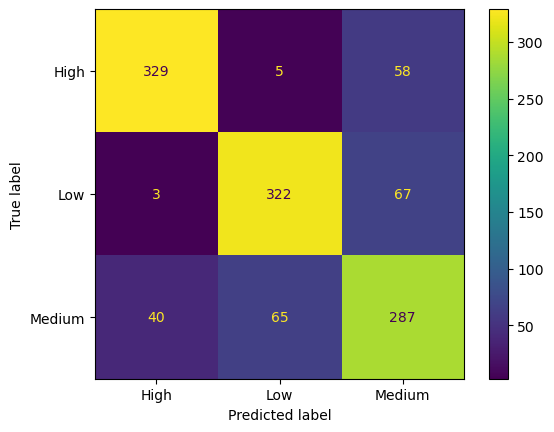

In [13]:
# Report and interpret the classification results.

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test_labels, y_pred_labels))

ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels)
plt.show()

## Step 3: Product recommendation system

Here you will recommend products that are similar to a selected product based on product-level features.

Use PCA to simplify the feature space before computing nearest neighbors.

In [14]:
# Create a list of numeric product features to use for recommendations.
# Include only modeling features that describe product behavior/performance.
# Do NOT include identifiers or text-only columns such as StockCode or Description.

product_features = [
    "AvgUnitPrice",
    "PriceStd",
    "TotalUnitsSold",
    "TotalRevenue",
    "NumInvoices",
    "UniqueCustomers",
    "CountriesSoldTo",
    "AvgQuantityPerInvoice",
    "CustomerPenetration",
    "RevenuePerCustomer",
    "UnitsPerCustomer",
    "InvoicePenetration",
]

print(product_features)

['AvgUnitPrice', 'PriceStd', 'TotalUnitsSold', 'TotalRevenue', 'NumInvoices', 'UniqueCustomers', 'CountriesSoldTo', 'AvgQuantityPerInvoice', 'CustomerPenetration', 'RevenuePerCustomer', 'UnitsPerCustomer', 'InvoicePenetration']


In [15]:
# Scale the product features and reduce dimensionality with PCA.
# In the sample solution, 3 components worked well for a compact but useful representation.

scaler_product = StandardScaler()
X_product_scaled = scaler_product.fit_transform(product_df[product_features])

pca_product = PCA(n_components=3, random_state=42)
X_product_pca = pca_product.fit_transform(X_product_scaled)

# Print
print("Explained variance ratio:", pca_product.explained_variance_ratio_)
print("Total variance retained:", round(pca_product.explained_variance_ratio_.sum(), 4))

Explained variance ratio: [0.47823254 0.25622972 0.14097462]
Total variance retained: 0.8754


In [17]:
# Fit a nearest-neighbors model on the PCA-transformed product features.
# Then choose one product and retrieve its nearest neighbors.

# Define model and fit
nn_model = NearestNeighbors(n_neighbors=6, metric="cosine")
nn_model.fit(X_product_pca)

# Change this index if you want to inspect a different product.
query_index = 0

distances, indices = nn_model.kneighbors([X_product_pca[query_index]])

# Use the returned indices to display the query product and its recommended products.
query_product = product_df.iloc[query_index][["StockCode", "Description", "Category"]]
print("Query product:")
print(query_product)

recommendations = product_df.iloc[indices[0][1:]][[
    "StockCode", "Description", "Category", "TotalRevenue", "UniqueCustomers"
]].copy()
recommendations["CosineDistance"] = distances[0][1:]

print("\nRecommended similar products:")
display(recommendations)

Query product:
StockCode                           10002
Description    INFLATABLE POLITICAL GLOBE
Category                    General Gifts
Name: 0, dtype: object

Recommended similar products:


,StockCode,Description,Category,TotalRevenue,UniqueCustomers,CosineDistance
2240,23078,ICE CREAM PEN LIP GLOSS,Stationery & Crafts,8077.31,159,0.000003
2166,22998,TRAVEL CARD WALLET KEEP CALM,Kids & Toys,4693.40,217,0.000051
844,21495,SKULLS AND CROSSBONES WRAP,Stationery & Crafts,5119.30,201,0.000090
1213,21967,PACK OF 12 SKULL TISSUES,General Gifts,4319.76,250,0.000148
1715,22536,MAGIC DRAWING SLATE PURDEY,General Gifts,3924.60,243,0.000360


## Step 4: Customer segmentation with clustering

You will cluster customers using behavioral features from the joined dataset.

The goal is to compare:
- **K-Means** for hard clustering
- **GMM** for probabilistic clustering

In [18]:
# Start from the joined dataset and remove extreme outliers.
# This helps prevent a very small number of unusual customers from dominating the clusters.

cluster_df = joined_df.copy()

mask = (
    (cluster_df["TotalSpend"] <= cluster_df["TotalSpend"].quantile(0.99))
    & (cluster_df["TotalUnits"] <= cluster_df["TotalUnits"].quantile(0.99))
    & (cluster_df["NumInvoices"] <= cluster_df["NumInvoices"].quantile(0.99))
)

cluster_df = cluster_df[mask].copy()
print("Rows used for clustering:", cluster_df.shape[0])

Rows used for clustering: 5785


In [19]:
# Build the clustering feature list.
# The share columns may vary depending on the prepared CSV version, so build them dynamically.

base_cluster_features = [
    "TotalUnits",
    "NumInvoices",
    "UniqueProducts",
    "CustomerTenureDays",
    "RecencyDays",
    "AvgUnitsPerInvoice",
    "PurchaseFrequency",
    "RecencyRatio",
    "DiversityRatio",
    "TopCategoryShare",
    "CategoryDiversity",
]

share_cols = [col for col in cluster_df.columns if col.startswith("Share_")]
cluster_features = [col for col in base_cluster_features + share_cols if col in cluster_df.columns]

# Print the final feature list after you create it.
print(cluster_features)

['TotalUnits', 'NumInvoices', 'UniqueProducts', 'CustomerTenureDays', 'RecencyDays', 'AvgUnitsPerInvoice', 'PurchaseFrequency', 'RecencyRatio', 'DiversityRatio', 'TopCategoryShare', 'CategoryDiversity', 'Share_StorageBags', 'Share_GeneralGifts', 'Share_HomeDecor', 'Share_KitchenDining', 'Share_StationeryCrafts']


In [20]:
# Apply light transformations to reduce skew in the highest-volume variables.
# Then scale the data and apply PCA.

for col in [
    "TotalUnits",
    "NumInvoices",
    "UniqueProducts",
    "CustomerTenureDays",
    "RecencyDays",
    "AvgUnitsPerInvoice",
]:
    if col in cluster_df.columns:
        cluster_df[col] = np.log1p(cluster_df[col])

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(cluster_df[cluster_features])

pca_cluster = PCA(n_components=2, random_state=42)
X_cluster_pca = pca_cluster.fit_transform(X_cluster_scaled)

# After fitting PCA, print the number of components and the variance retained.
print("Number of PCA components:", pca_cluster.n_components_)
print("Variance retained:", round(pca_cluster.explained_variance_ratio_.sum(), 4))

Number of PCA components: 2
Variance retained: 0.4745


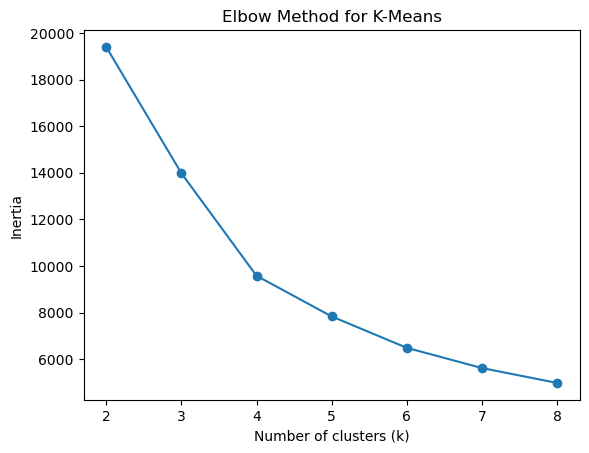

In [21]:
# Use the elbow method to explore the best number of clusters for K-Means.

inertias = []
k_values = range(2, 9)

# Use a for loop to fit K-Means for each k and store the inertia.
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_pca)
    inertias.append(km.inertia_)

plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

# Choose best_k based on the "elbow" point where the curve starts to level off.

In [22]:
# Fit the final K-Means model using the k you selected from the elbow plot.
# Replace the value below after you inspect the plot.

best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df["KMeansCluster"] = kmeans.fit_predict(X_cluster_pca)

print(cluster_df["KMeansCluster"].value_counts().sort_index())

KMeansCluster
0    1550
1     625
2    2456
3    1154
Name: count, dtype: int64


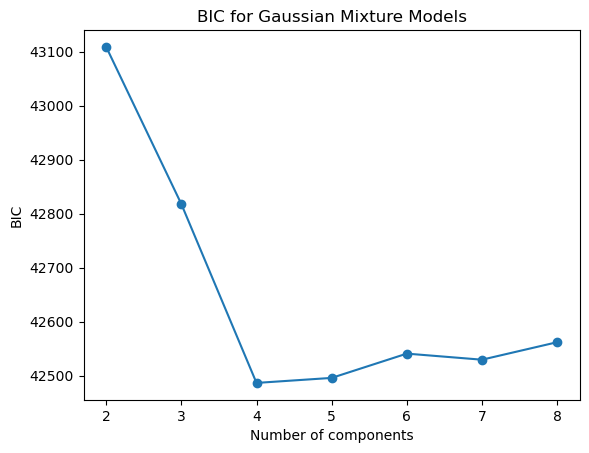

In [23]:
# Use BIC to choose the number of components for GMM.

bic_scores = []
gmm_range = range(2, 9)

# Use a for loop to fit a GMM for each value and store the BIC score.
for n in gmm_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_cluster_pca)
    bic_scores.append(gmm.bic(X_cluster_pca))

plt.plot(list(gmm_range), bic_scores, marker="o")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture Models")
plt.show()

# Choose best_gmm_n as the number of components with the lowest BIC.

In [24]:
# Fit the final GMM model using the number of components with the lowest BIC.
# Replace the value below after you inspect the BIC plot.

best_gmm_n = int(gmm_range[np.argmin(bic_scores)])

gmm_final = GaussianMixture(n_components=best_gmm_n, random_state=42)
cluster_df["GMMCluster"] = gmm_final.fit_predict(X_cluster_pca)

print(cluster_df["GMMCluster"].value_counts().sort_index())

GMMCluster
0    2816
1    1363
2     364
3    1242
Name: count, dtype: int64


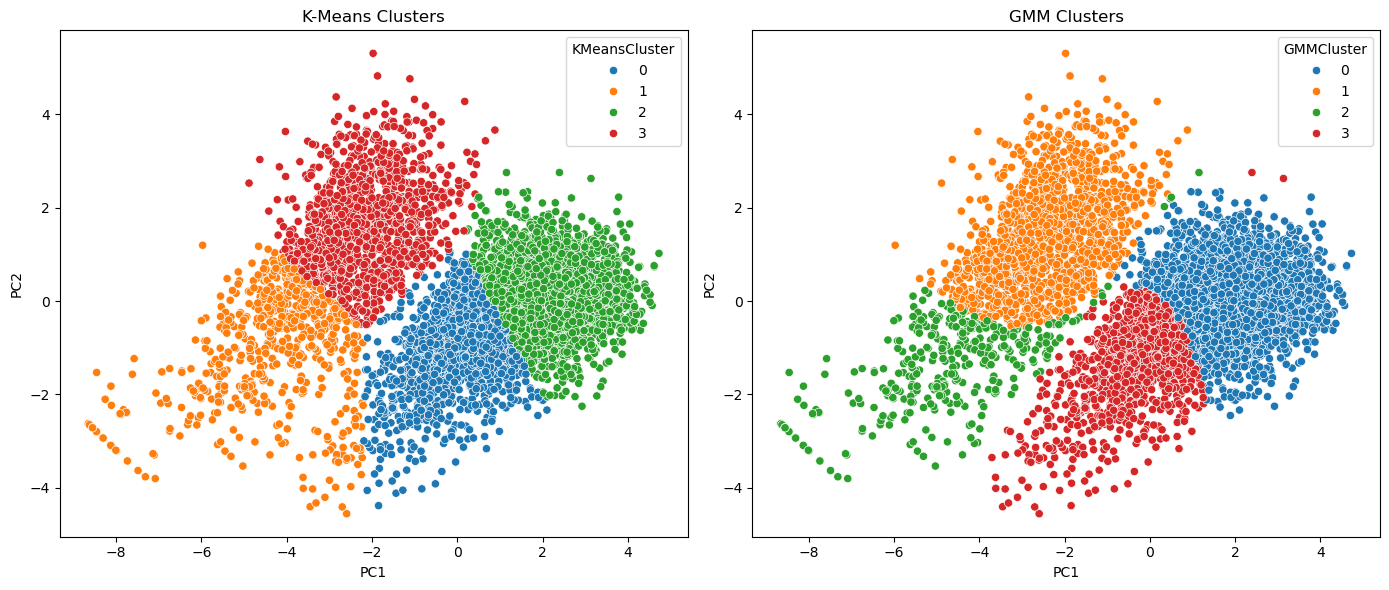

In [25]:
# Visualize the clusters using the first two principal components.

cluster_plot_df = pd.DataFrame({
    "PC1": X_cluster_pca[:, 0],
    "PC2": X_cluster_pca[:, 1],
    "KMeansCluster": cluster_df["KMeansCluster"].values,
    "GMMCluster": cluster_df["GMMCluster"].values,
})

# Build a plotting DataFrame that includes:
# - PC1
# - PC2
# - KMeansCluster
# - GMMCluster

# Then create side-by-side scatterplots to compare the two clustering methods.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=cluster_plot_df, x="PC1", y="PC2", hue="KMeansCluster", palette="tab10", ax=axes[0])
axes[0].set_title("K-Means Clusters")

sns.scatterplot(data=cluster_plot_df, x="PC1", y="PC2", hue="GMMCluster", palette="tab10", ax=axes[1])
axes[1].set_title("GMM Clusters")

plt.tight_layout()
plt.show()

## Reflection questions

Answer these in markdown cells below the relevant sections.

1. Why was it important to remove variables like `TotalSpend` from the classification feature set?
I removed TotalSpend because it basically gives away the answer. If I’m trying to classify customers, using something like total spend can cause data leakage since it’s too directly tied to the outcome. It would make the model look better than it actually is, but it wouldn’t generalize well to new data.

2. How did PCA help in the classification, recommendation, and clustering tasks?
PCA helped by reducing the number of features while still keeping most of the important information. That made the models run more efficiently and also reduced noise. For classification, it improved performance by focusing on the main patterns. For recommendations, it made similarity comparisons cleaner. And for clustering, it made it easier to visualize and separate groups.

3. What differences do you notice between the K-Means and GMM clustering results?
K-Means gave more clear-cut clusters where each data point belongs to just one group. GMM was more flexible since it uses probabilities, so some points could kind of belong to multiple clusters. Overall, K-Means felt more rigid, while GMM captured more of the underlying structure in the data.

4. Which customer or product insights seem the most actionable from a business perspective?
The most useful insights are around grouping similar customers and products. For example, identifying high-value customers or frequently purchased product groups can help with targeted marketing or recommendations. The product similarity part is also really actionable since it can be used for upselling or cross-selling.